Purpose: Run XGBoost regression for both LICOR physiological markers (stomatal conductance `cond` & C assimilation `phys`) with CAM genes as the features.<br>
Author: Anna Pardo<br>
Date initiated: Feb. 20, 2026

In [44]:
# load modules & functions needed
from xgboost import XGBRegressor
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn import metrics
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import PredictionErrorDisplay
from sklearn.metrics import mean_squared_error
import random
import scipy
import os

## Section 1: Define functions

In [67]:
def genotype_split_selection(meta,pctdf,minval=15,maxval=25):
    p=0
    gtselec = []
    while p<minval:
        gt = random.choice(list(meta["genotype"]))
        pct = pctdf[pctdf["genotype"]==gt].percent.item()
        p = p+pct
        if p<maxval:
            gtselec.append(gt)
            pctdf = pctdf[pctdf["genotype"]!=gt]
        else:
            p = p-pct
    #print("Test percentage: ",str(p))
    return [gtselec,p]

In [68]:
# define a function to get a sample list for the TEST data
def test_samps(meta,pctdf,minval=15,maxval=25):
    gtlist = genotype_split_selection(meta,pctdf,minval,maxval)[0]
    testp = genotype_split_selection(meta,pctdf,minval,maxval)[1]
    subdf = meta[meta["genotype"].isin(gtlist)]
    return {"test_genotypes":gtlist,"sample_ids":list(subdf["sample_name"]),"test_pct":testp}

In [81]:
# split the training set for cross-validation: ~25%
## set up a function to do this
def split_train_val(trainx,trainy,testgts,meta,minval=15,maxval=25):
    submd = meta[~meta["genotype"].isin(testgts)]
    traincounts = submd.groupby("genotype").count().reset_index()[["genotype","sample_name"]]
    traincounts["percent"] = (traincounts["sample_name"]/len(submd.index))*100
    cvinfo = test_samps(submd,traincounts,minval,maxval)
    
    valx = trainx[~trainx.index.isin(cvinfo["sample_ids"])]
    tx = trainx[trainx.index.isin(cvinfo["sample_ids"])]
    
    valy = trainy[~trainy.index.isin(cvinfo["sample_ids"])]
    ty = trainy[trainy.index.isin(cvinfo["sample_ids"])]
    
    return tx,valx,ty,valy

In [6]:
# function from tutorial on hyperparameter tuning: https://macalusojeff.github.io/post/HyperparameterTuningXGB/
def sample_from_param_distributions(param_distributions: dict) -> dict:
    """
    Sample a value from each parameter distribution defined in param_distributions.

    Parameters:
    - param_distributions (dict): Dictionary where keys are parameter names and values are either:
        - scipy.stats distribution objects for continuous distributions.
        - Lists or numpy arrays for discrete choices.

    Returns:
    - sampled_values (dict): Dictionary containing sampled values corresponding to each parameter.
    """
    sampled_values = {}
    for param, distribution in param_distributions.items():
        if isinstance(distribution, scipy.stats._distn_infrastructure.rv_frozen):
            sampled_values[param] = distribution.rvs()
        elif isinstance(distribution, list) or isinstance(distribution, np.ndarray):
            sampled_values[param] = np.random.choice(distribution)
        else:
            raise ValueError(f"Unsupported distribution type for parameter '{param}'")

    return sampled_values

In [7]:
# set up a function for identification of optimal hyperparameters

def opt_hyperparams(niter,nestim,estop,trainx,trainy,valx,valy):
    optimal_params = {}
    best_score = -np.inf
    for iteration in range(niter):
        # Sample values from the distributions
        sampled_params = sample_from_param_distributions(param_distributions)

        # Train the model, get the performance on the validation set
        model = XGBRegressor(n_estimators=nestim, early_stopping_rounds=estop,
                                 n_jobs=-1, random_state=46, **sampled_params)

        # Perform the tuning with train/test split
        # I don't want k-folds because of data leakage potential
        # Train/test split with the validation data set for early stopping
        model.fit(trainx, trainy, eval_set=[(valx, valy)], verbose=False)
        predictions = model.predict(valx)
        neg_mean_squared_error = -mean_squared_error(y_true=valy, y_pred=predictions)

        # Set the optimal parameters if the performance is better
        if neg_mean_squared_error > best_score:
            best_score = neg_mean_squared_error
            optimal_params = sampled_params
            
    print("Best score (negative MSE): ",str(best_score))
    return optimal_params

In [8]:
def retrain_optparams(optimal_params,trainx,trainy):
    tuned_model = XGBRegressor(**optimal_params, n_jobs=-1, random_state=46)
    tuned_model.fit(trainx, trainy)

    return tuned_model

In [31]:
# function to plot predicted vs. actual Y values
def plotpreds(y_test,preds,filepath,customtitle=""):
    fig,ax = plt.subplots(figsize=(10,10))
    PredictionErrorDisplay.from_predictions(
        y_test,
        preds,
        kind="actual_vs_predicted",
        ax=ax,
        scatter_kwargs={"alpha": 0.5},
    )
    plt.title(customtitle)
    plt.savefig(filepath+".png",dpi=200,bbox_inches="tight")
    plt.savefig(filepath+".pdf",dpi=200,bbox_inches="tight")
    plt.savefig(filepath+".svg",dpi=200,bbox_inches="tight")

In [10]:
# define a function to load data (already log-transformed) & output data & metadata
## also: assumes data are already subsetted to drought only & have dropped single-sample genotypes
def load_clean_data(filepath):
    df = pd.read_csv(filepath,sep="\t",header="infer")
    md = df[["sample_name","genotype","treat","ZT","photo","cond"]]
    
    # get genotype sample counts & percentages
    counts = md.groupby("genotype").count().reset_index()[["genotype","sample_name"]].rename(columns={"sample_name":"sampcount"})
    counts["percent"] = (counts["sampcount"]/len(md.index))*100
    
    # drop metadata from logTPM & set sample name as index
    logtpm = df.set_index("sample_name").drop(["genotype","treat","ZT","photo","cond"],axis=1)
    
    return {"logTPM":logtpm,"metadata":md,"genotype_percentages":counts}

In [82]:
# define a function to set up X & y data (train, test, & val) for each physiological marker (y)
## want to make sure that I'm running models on the same genotype sets for each marker, I think
def make_xy_sets(datadict,minval=15,maxval=25):
    # where datadict = the output of load_clean_data()
    y = datadict["metadata"][["sample_name","photo","cond"]].set_index("sample_name")
    x = datadict["logTPM"]
    
    # get test data
    testinfo = test_samps(datadict["metadata_remaining"],datadict["genotype_percentages"],minval,maxval)
    print("Test set genotypes: ",testinfo["test_genotypes"])
    print("Test data percentage: ",str(testinfo["test_pct"]))
    
    # split train & test: X
    X_train = x[~x.index.isin(testinfo["sample_ids"])]
    X_test = x[x.index.isin(testinfo["sample_ids"])]
    
    # split train & test: y
    y_train = y[~y.index.isin(testinfo["sample_ids"])]
    y_test = y[y.index.isin(testinfo["sample_ids"])]
    
    # do train-validation split
    X_train,X_val,y_train,y_val = split_train_val(X_train,y_train,testinfo["test_genotypes"],datadict["metadata"])
    
    outdict = {
        "X":{"train":X_train,"val":X_val,"test":X_test},
        "Y":{"train":y_train,"val":y_val,"test":y_test},
        "test_data_info":testinfo
    }
    return outdict
    

In [77]:
# run through modeling for the output of make_xy_sets()
def run_xgboost(physcol,xydict,params_dict,niter=250,nestim=10000,estop=125,baseline=True):
    # set up y objects
    ytrain = xydict["Y"]["train"][physcol]
    yval = xydict["Y"]["val"][physcol]
    ytest = xydict["Y"]["test"][physcol]
    
    # set up x objects
    xtrain = xydict["X"]["train"]
    xval = xydict["X"]["val"]
    xtest = xydict["X"]["test"]
    
    # run a baseline model if baseline=True
    if baseline==True:
        baseline_model = XGBRegressor(n_jobs=-1, random_state=46)
        baseline_model.fit(xtrain,ytrain)
        scores = {
            "R2":baseline_model.score(xtest,ytest),
            "MSE":mean_squared_error(ytest, baseline_model.predict(xtest))
        }
        
        print("Baseline model -")
        print("R^2: ", scores["R2"])
        print("MSE: ", scores["MSE"])
        
    # tune hyperparameters
    optparams = opt_hyperparams(niter,nestim,estop,xtrain,ytrain,xval,yval)
    tuned = retrain_optparams(optparams,xtrain,ytrain)
    
    # get scores & predictions
    preds = tuned.predict(xtest)
    
    tuned_scores = {
        "R2":tuned.score(xtest,ytest),
        "MSE":mean_squared_error(ytest, baseline_model.predict(xtest))
    }
    print("Tuned model -")
    print("R^2: ", tuned_scores["R2"])
    print("MSE: ", tuned_scores["MSE"])
    
    outdir = "./"+physcol+"_prediction_plots/"
    if not os.path.exists(outdir):
        os.makedirs(outdir)
        
    fname = ""
    for i in xydict["test_data_info"]["test_genotypes"]:
        fname = fname+str(i)+"_"
    fname = fname+"test"
    plotpreds(ytest,preds,
              filepath=os.path.join(outdir,fname),
              customtitle="Test genotypes: "+fname.split("_t")[0]+", Y="+physcol+", R^2="+str(tuned_scores["R2"]))
    
    return {"model":tuned,"predictions":preds,"scores":tuned_scores}

## Section 2: Run models

In [17]:
# Define the parameter distributions for hyperparameter tuning
# Using this guide: https://machinelearningmastery.com/configure-gradient-boosting-algorithm/
# Parameter documentation: https://xgboost.readthedocs.io/en/stable/parameter.html
param_distributions = {
    "learning_rate": scipy.stats.uniform(loc=0.003, scale=0.19),  # Default is 0.3. Ranges from loc to loc+scale.
    "subsample": scipy.stats.uniform(loc=0.5, scale=0.5),  # Default is 1
    "colsample_bytree": scipy.stats.uniform(loc=0.5, scale=0.5),  # Default is 1
    "min_child_weight": [1, 3, 5, 7],  # Default is 1
    "max_depth": np.append(0, np.arange(3, 16)),  # Default is 6
    "alpha": [0, 0.01, 1, 2, 5, 7, 10, 50, 100],  # Default is 0. AKA reg_alpha.
    "lambda": [0, 0.01, 1, 5, 10, 20, 50, 100]  # Default is 0. AKA reg_lambda.
}

In [18]:
# load data
datainfo = load_clean_data("./CAMgenes_logTPM_phys_forxgboost.txt")

In [27]:
datainfo["metadata"].head()

,sample_name,genotype,treat,ZT,photo,cond
0,Y111,18,D,1.0,2.627596,0.026132
1,Y123,18,D,1.0,2.679172,0.021603
2,Y120,18,D,3.0,1.211527,0.007856
3,Y125,18,D,3.0,1.289725,0.009783
4,Y129,18,D,3.0,1.549238,0.010471


In [29]:
len(datainfo["metadata"]["genotype"].unique())

12

In [83]:
datainfo["metadata_remaining"] = datainfo["metadata"]

Test set genotypes:  ['1AB']
Test data percentage:  22.596153846153847
Baseline model -
R^2:  -0.5073975545090936
MSE:  0.00011789403978971312
Best score (negative MSE):  -9.464887269296786e-05
Tuned model -
R^2:  -0.33247551857985913
MSE:  0.00011789403978971312
Baseline model -
R^2:  -0.30524530939495587
MSE:  1.486895783826916
Best score (negative MSE):  -1.0924542083429665
Tuned model -
R^2:  -0.2832746175085621
MSE:  1.486895783826916


ValueError: can only convert an array of size 1 to a Python scalar

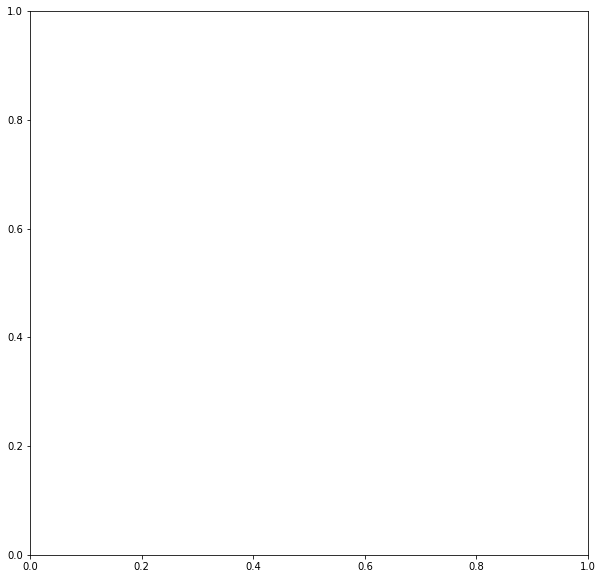

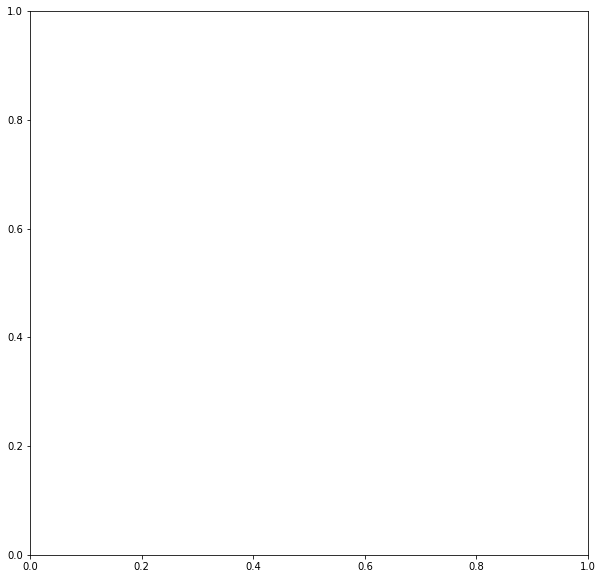

In [84]:
tested_gts = []
dictlist = []

while len(tested_gts)<len(datainfo["metadata"]["genotype"].unique()):
    xydict = make_xy_sets(datainfo)
    for i in xydict["test_data_info"]["test_genotypes"]:
        tested_gts.append(i)
    # drop previously tested genotypes from the metadata
    datainfo["metadata_remaining"] = datainfo["metadata_remaining"][~datainfo["metadata_remaining"]["genotype"].isin(tested_gts)]
    
    # run XGBoost on stomatal conductance
    xgbres_cond = run_xgboost("cond",xydict,param_distributions,niter=200,estop=100)
    dictlist.append(xgbres_cond)
    plt.clf()
    plt.cla()
    
    xgbres_photo = run_xgboost("photo",xydict,param_distributions,niter=200,estop=100)
    dictlist.append(xgbres_photo)
    plt.clf()
    plt.cla()

In [85]:
tested_gts

['1AB']

In [53]:
len(tested_gts)

11